# Compare Fraud Scenarios, Difficulty, and Camouflage

This tutorial builds a small scenario benchmark. It compares a baseline world with two resolved difficulty levels and a camouflage run, then visualizes what changed.

These measurements describe generated fraud evidence—not detector quality. Labels are intentionally unresolved, so model metrics belong in the ML evaluation tutorials.

## Notebook package

This tutorial assumes Matplotlib is installed in the notebook kernel. If needed, run `%pip install matplotlib` once and rerun the notebook.

## 1. Define a fair comparison

All runs use the same seed, population, payment volume, fraud workflow, and time window. Only the benchmark control changes: no benchmark for the baseline, resolved difficulty 7 or 10, or M13 camouflage.

In [1]:
import copy
import json
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import polars as pl

import fraudtwin
from fraudtwin.config import SimulationRunConfig, load_config

root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "configs" / "minimal.yaml").is_file())
base = load_config(root / "configs" / "minimal.yaml")
base_values = base.model_dump(mode="python")
base_values["payments"]["daily_target"] = 100
base_values["simulation"]["duration_days"] = 10
base_values["simulation"]["seed"] = 2501
base_values["population"].update({"customers": 100, "accounts": 200, "cards": 200, "merchants": 30, "devices": 200, "pix_keys": 100})
base_values["behavior"]["amount_max"] = 100
base_values["fraud"].update({"enabled": True, "target_rate": 0.05})
base_values["fraud_workflow"]["enabled"] = True

def build_config(control: str | None) -> SimulationRunConfig:
    values = copy.deepcopy(base_values)
    if control in {"Difficulty 7", "Difficulty 10"}:
        values["benchmark"] = {"difficulty": int(control.rsplit(" ", 1)[1])}
    elif control == "Camouflage":
        values["stress"] = {
            "camouflage": 0.80,
            "feature_camouflage": 0.85,
            "relation_camouflage": 0.75,
            "cohort": {
                "strategy": "same_rail_and_profile",
                "profile_dimensions": ["spending_level", "country", "merchant_category", "typical_payment_hour", "trusted_device"],
                "minimum_size": 3,
                "fallback": "same_rail",
            },
        }
    return SimulationRunConfig.model_validate(values)

configs = {label: build_config(control) for label, control in [("Baseline", None), ("Difficulty 7", "Difficulty 7"), ("Difficulty 10", "Difficulty 10"), ("Camouflage", "Camouflage")]}

## 2. Generate the comparable runs

Each run is generated independently from the same base configuration. The manifest records the resolved difficulty or camouflage settings, which we inspect later instead of printing the full manifest.

In [2]:
runs = {label: fraudtwin.generate(config) for label, config in configs.items()}
summary_rows = []
scenario_rows = []
amount_rows = []
for label, result in runs.items():
    records = result.behavior.fraud_records
    known_truth = [record.fraud_truth for record in records if record.fraud_truth is not None]
    difficulty = result.manifest.difficulty or {}
    camouflage = result.manifest.camouflage or {}
    resolved_global = camouflage.get("resolved_global", {})
    summary_rows.append({"Scenario": label, "Run ID": result.run_id, "Payments": len(result.behavior.payments), "Fraud records": len(records), "True fraud records": sum(value is True for value in known_truth), "Truth share": sum(value is True for value in known_truth) / len(known_truth) if known_truth else None, "Difficulty": difficulty.get("requested_difficulty"), "Camouflage": resolved_global.get("camouflage")})
    for record in records:
        scenario_rows.append({"Scenario": label, "Fraud type": record.scenario_type, "Truth": record.fraud_truth})
        amount_rows.append({"Scenario": label, "Amount": record.amount, "Truth": record.fraud_truth})
benchmark_summary = pl.DataFrame(summary_rows)
scenario_frame = pl.DataFrame(scenario_rows)
amount_frame = pl.DataFrame(amount_rows)

In [3]:
scenario_names = sorted(scenario_frame["Fraud type"].unique().to_list())
assert scenario_names and scenario_frame.height > 0

## 3. Plot the benchmark summary

The first figure shows scale and known fraud evidence. A lower truth share is not automatically better or worse; it means the generated fraud-record set contains more unresolved or hard-negative cases.

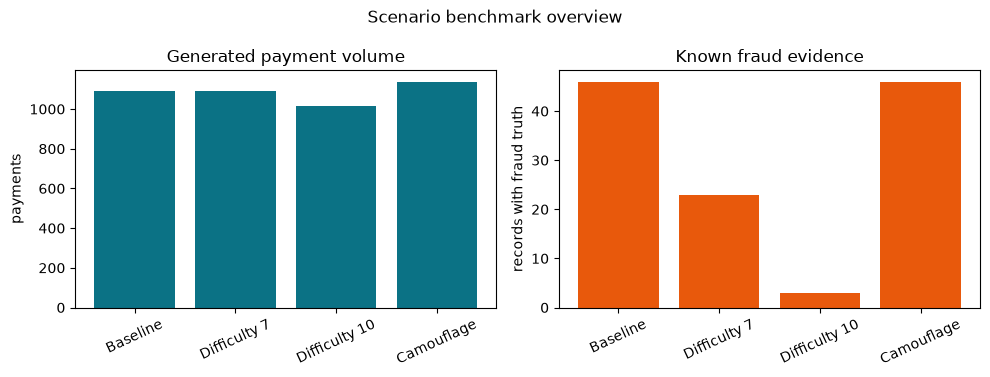

In [4]:
labels = benchmark_summary["Scenario"].to_list()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].bar(labels, benchmark_summary["Payments"].to_list(), color="#0b7285")
axes[0].set(title="Generated payment volume", ylabel="payments")
axes[1].bar(labels, benchmark_summary["True fraud records"].to_list(), color="#e8590c")
axes[1].set(title="Known fraud evidence", ylabel="records with fraud truth")
for axis in axes: axis.tick_params(axis="x", rotation=25)
fig.suptitle("Scenario benchmark overview"); fig.tight_layout(); plt.show(); plt.close(fig)

## 4. Plot the scenario mix

This stacked chart checks that the difficulty controls do not silently replace the fraud objectives with a different scenario population.

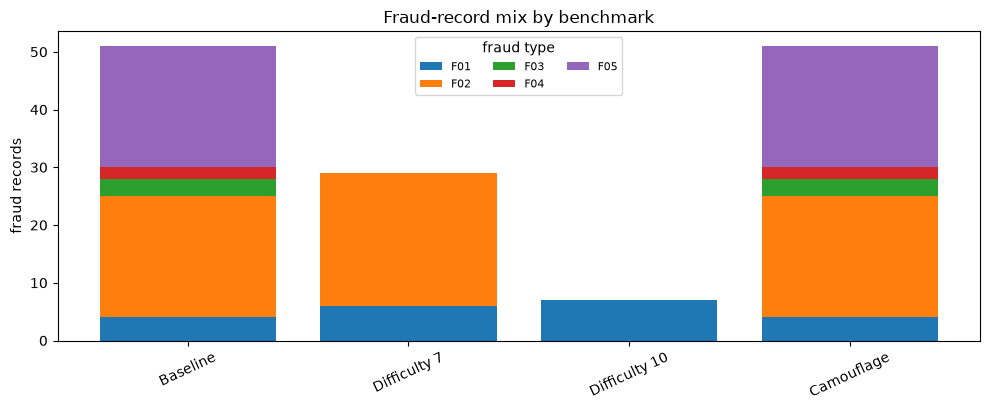

In [5]:
fig, axis = plt.subplots(figsize=(10, 4.2))
bottom = [0] * len(labels)
for fraud_type in scenario_names:
    values = [int(scenario_frame.filter((pl.col("Scenario") == label) & (pl.col("Fraud type") == fraud_type)).height) for label in labels]
    axis.bar(labels, values, bottom=bottom, label=fraud_type)
    bottom = [current + value for current, value in zip(bottom, values)]
axis.set(title="Fraud-record mix by benchmark", ylabel="fraud records")
axis.tick_params(axis="x", rotation=25); axis.legend(title="fraud type", ncol=3, fontsize=8)
fig.tight_layout(); plt.show(); plt.close(fig)

## 5. Plot the fraud-amount distributions

This is a descriptive check of the generated evidence. It is not a classifier score and should not replace a matured-label evaluation.

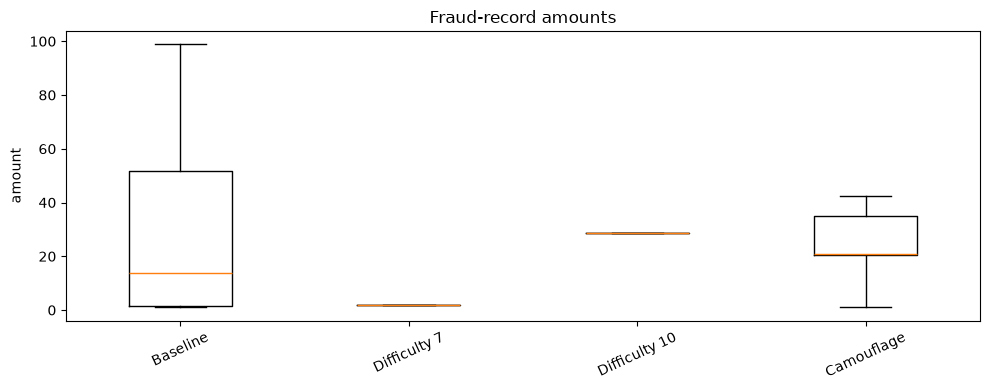

In [6]:
amount_values = [amount_frame.filter(pl.col("Scenario") == label)["Amount"].drop_nulls().to_list() for label in labels]
fig, axis = plt.subplots(figsize=(10, 4))
axis.boxplot(amount_values, tick_labels=labels, showfliers=False)
axis.set(title="Fraud-record amounts", ylabel="amount")
axis.tick_params(axis="x", rotation=25); fig.tight_layout(); plt.show(); plt.close(fig)

## 6. Inspect compact benchmark tables

The plots show the pattern; these tables preserve the exact run identities and measurements without dumping entire manifests.

In [7]:
benchmark_summary.with_columns(pl.col("Truth share").round(3))

Scenario,Run ID,Payments,Fraud records,True fraud records,Truth share,Difficulty,Camouflage
str,str,i64,i64,i64,f64,i64,f64
"""Baseline""","""RUN-f2bd687be19810c7""",1092,51,46,0.902,null,null
"""Difficulty 7""","""RUN-26360e676647d13f""",1092,29,23,0.793,7,null
"""Difficulty 10""","""RUN-28f74200f6f7e3bf""",1015,7,3,0.429,10,null
"""Camouflage""","""RUN-e48a8943d4228423""",1138,51,46,0.902,null,0.8


In [8]:
scenario_frame.group_by(["Scenario", "Fraud type"]).len(name="Records").sort(["Scenario", "Fraud type"])

Scenario,Fraud type,Records
str,str,u32
"""Baseline""","""F01""",4
"""Baseline""","""F02""",21
"""Baseline""","""F03""",3
"""Baseline""","""F04""",2
"""Baseline""","""F05""",21
…,…,…
"""Camouflage""","""F04""",2
"""Camouflage""","""F05""",21
"""Difficulty 10""","""F01""",7


In [9]:
amount_frame.group_by("Scenario").agg([pl.col("Amount").quantile(0.25).alias("Q1"), pl.col("Amount").median().alias("Median"), pl.col("Amount").quantile(0.75).alias("Q3")]).sort("Scenario")

Scenario,Q1,Median,Q3
str,f64,f64,f64
"""Baseline""",1.7,13.83,52.16
"""Camouflage""",20.63,20.72,34.96
"""Difficulty 10""",28.58,28.58,28.58
"""Difficulty 7""",2.0,2.0,2.0


## 7. Verify the controls that actually resolved

Difficulty levels are resolved by FraudTwin. Showing the resolved values prevents a benchmark from claiming that two runs differ when the generator received the same effective controls. Camouflage is reported separately because it is a different stress mechanism.

In [10]:
control_rows = []
for label in ("Difficulty 7", "Difficulty 10"):
    resolved = runs[label].manifest.difficulty["resolved_controls"]
    for name, value in resolved.items():
        control_rows.append({"Scenario": label, "Control": name, "Resolved value": value})
control_table = pl.DataFrame(control_rows)
control_table

Scenario,Control,Resolved value
str,str,f64
"""Difficulty 7""","""fraud_legitimate_overlap""",0.666667
"""Difficulty 7""","""behavioral_deviation""",0.666667
"""Difficulty 7""","""scenario_subtlety""",0.666667
"""Difficulty 7""","""noise_hard_negatives""",0.666667
"""Difficulty 7""","""prevalence""",0.666667
…,…,…
"""Difficulty 10""","""scenario_subtlety""",1.0
"""Difficulty 10""","""noise_hard_negatives""",1.0
"""Difficulty 10""","""prevalence""",1.0


In [11]:
camouflage_table = benchmark_summary.filter(pl.col("Scenario") == "Camouflage").select(["Scenario", "Camouflage"])
camouflage_table

Scenario,Camouflage
str,f64
"""Camouflage""",0.8


## 8. Save a small reproducibility report

The report contains the compact benchmark summary and scenario counts. The temporary directory keeps this tutorial self-contained; a production run would write the artifact to its run directory.

In [12]:
scenario_counts = scenario_frame.group_by(["Scenario", "Fraud type"]).len(name="Records").to_dicts()
report_payload = {"benchmark_summary": benchmark_summary.to_dicts(), "scenario_counts": scenario_counts}
with TemporaryDirectory(prefix="fraudtwin-scenario-benchmark-") as tmp:
    report_path = Path(tmp) / "benchmark-summary.json"
    report_path.write_text(json.dumps(report_payload, default=str, indent=2), encoding="utf-8")
    artifact_summary = pl.DataFrame([{"Artifact": report_path.name, "Bytes": report_path.stat().st_size, "Runs": len(runs), "Scenario types": len(scenario_names)}])
    assert report_path.stat().st_size > 100
artifact_summary

Artifact,Bytes,Runs,Scenario types
str,i64,i64,i64
"""benchmark-summary.json""",2279,4,5


## 9. Interpret the result

This benchmark answers: did the generator create comparable worlds, resolve the requested controls, preserve the scenario mix, and produce explainable amount distributions? It does not answer whether a fraud model catches the cases. For that, wait for label maturity and evaluate one fixed detector protocol across these same runs.

In [13]:
assert set(runs) == {"Baseline", "Difficulty 7", "Difficulty 10", "Camouflage"}
assert all(len(result.behavior.payments) >= 1_000 for result in runs.values())
assert runs["Difficulty 7"].manifest.difficulty["requested_difficulty"] == 7
assert runs["Difficulty 10"].manifest.difficulty["requested_difficulty"] == 10
assert runs["Difficulty 7"].manifest.difficulty["resolved_controls"] != runs["Difficulty 10"].manifest.difficulty["resolved_controls"]
assert runs["Camouflage"].manifest.camouflage["resolved_global"]["camouflage"] == 0.8
assert scenario_frame.height > 0 and amount_frame.height > 0